<a href="https://colab.research.google.com/github/jvargasa2/BigDataScraping/blob/main/Ejercicio_2_Scraaping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Open Data del Banco Mundial con Python

Este cuaderno muestra cómo consumir datos desde la API del Banco Mundial,
limpiar respuestas en formato JSON y realizar análisis exploratorio con pandas
y visualización con matplotlib.

Indicadores analizados:
- PIB per cápita (USD)
- Acceso a electricidad (% población)

Países: Bolivia, Perú, Chile, Argentina, Colombia, Brasil, México y Paraguay  
Periodo: 2015–2023

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# 🏋️  EJERCICIO 1 — Tu turno
# ════════════════════════════════════════════════════════════════════════════
#
# Consulta un SEGUNDO indicador del Banco Mundial y compáralo con el PIB.
#
# Indicadores sugeridos:
#   'SP.POP.TOTL'    → Población total
#   'SE.ADT.LITR.ZS' → Tasa de alfabetización adultos (%)
#   'SH.XPD.CHEX.GD.ZS' → Gasto en salud (% del PIB)
#   'EG.ELC.ACCS.ZS' → Acceso a electricidad (% población)
#
# PASOS:
#   1. Define el nuevo indicador en la variable `indicador2`
#   2. Realiza la consulta a la API (mismos países, años 2015-2023)
#   3. Construye un DataFrame limpio llamado `df_indicador2`
#   4. Combínalo con df_pib usando pd.merge() por 'codigo' y 'anio'
#   5. Crea un scatter plot: eje X = pib_pc_usd, eje Y = nuevo indicador
#      Cada punto es un país-año; usa colores distintos por país
# ════════════════════════════════════════════════════════════════════════════

# --- Tu código aquí ---
indicador2 = '___'  # Reemplaza con el código del indicador elegido
nombre_indicador2 = '___'  # Nombre legible, ej: 'Acceso a electricidad (%)'

# url2 = ...
# response2 = ...
# df_indicador2 = ...

# df_combinado = pd.merge(df_pib, df_indicador2, on=['codigo', 'anio'])
# -- Scatter plot --

print("💡 Pista: La estructura de la URL es idéntica, solo cambia el indicador.")
print("   Recuerda que algunos indicadores tienen muchos valores None.")

💡 Pista: La estructura de la URL es idéntica, solo cambia el indicador.
   Recuerda que algunos indicadores tienen muchos valores None.


In [1]:
# Instalación de librerías adicionales
!pip install beautifulsoup4 lxml tinydb --quiet
print("✅ Librerías instaladas correctamente")
# ── Importaciones globales ─────────────────────────────────────────────────
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xml.etree.ElementTree as ET
import io
import time
import warnings
from bs4 import BeautifulSoup
from datetime import datetime
from tinydb import TinyDB, Query
from IPython.display import display, HTML, JSON

warnings.filterwarnings('ignore')

# Estilo para gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

print("✅ Todas las librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   requests {requests.__version__}")

✅ Librerías instaladas correctamente
✅ Todas las librerías importadas correctamente
   pandas  2.2.2
   requests 2.32.4


In [2]:
# ── Demo: API del Banco Mundial ────────────────────────────────────────────
# Indicador NY.GDP.PCAP.CD = PIB per cápita (USD corrientes)
# Documentación: https://datahelpdesk.worldbank.org/knowledgebase/articles/898581

paises = ['BOL', 'PER', 'CHL', 'ARG', 'COL', 'BRA', 'MEX', 'PRY']
indicador = 'NY.GDP.PCAP.CD'  # PIB per cápita USD

url = f"https://api.worldbank.org/v2/country/{';'.join(paises)}/indicator/{indicador}"
params = {
    'format': 'json',
    'per_page': 100,
    'date': '2015:2023'
}

print(f"📡 Consultando: {url}")
print(f"   Parámetros: {params}")

response = requests.get(url, params=params)
print(f"\n📊 Código de estado HTTP: {response.status_code}")
print(f"   URL final: {response.url[:80]}...")

📡 Consultando: https://api.worldbank.org/v2/country/BOL;PER;CHL;ARG;COL;BRA;MEX;PRY/indicator/NY.GDP.PCAP.CD
   Parámetros: {'format': 'json', 'per_page': 100, 'date': '2015:2023'}

📊 Código de estado HTTP: 200
   URL final: https://api.worldbank.org/v2/country/BOL;PER;CHL;ARG;COL;BRA;MEX;PRY/indicator/N...


In [4]:
# ── Parsear y limpiar la respuesta ─────────────────────────────────────────
data_raw = response.json()

# La API del Banco Mundial devuelve una lista con 2 elementos:
# [0] = metadatos (páginas, total de registros)
# [1] = los datos
print("🔍 Estructura de la respuesta:")
print(f"   Tipo: {type(data_raw)}")
print(f"   Metadatos: {data_raw[0]}")
print(f"\n   Primer registro de datos:")
print(json.dumps(data_raw[1][0], indent=2))

# Construir DataFrame limpio
registros = []
for item in data_raw[1]:
    if item['value'] is not None:  # Ignorar valores nulos
        registros.append({
            'pais':      item['country']['value'],
            'codigo':    item['countryiso3code'],
            'anio':      int(item['date']),
            'pib_pc_usd': round(item['value'], 4)
        })

df_pib = pd.DataFrame(registros).sort_values(['pais', 'anio'])
print(f"\n✅ DataFrame creado: {df_pib.shape[0]} filas × {df_pib.shape[1]} columnas")
df_pib.head(10)

🔍 Estructura de la respuesta:
   Tipo: <class 'list'>
   Metadatos: {'page': 1, 'pages': 1, 'per_page': 100, 'total': 72, 'sourceid': '2', 'lastupdated': '2026-02-24'}

   Primer registro de datos:
{
  "indicator": {
    "id": "NY.GDP.PCAP.CD",
    "value": "GDP per capita (current US$)"
  },
  "country": {
    "id": "AR",
    "value": "Argentina"
  },
  "countryiso3code": "ARG",
  "date": "2023",
  "value": 14261.8465667948,
  "unit": "",
  "obs_status": "",
  "decimal": 1
}

✅ DataFrame creado: 72 filas × 4 columnas


,pais,codigo,anio,pib_pc_usd
8,Argentina,ARG,2015,13679.6265
7,Argentina,ARG,2016,12699.9623
6,Argentina,ARG,2017,14532.5009
5,Argentina,ARG,2018,11752.7999
4,Argentina,ARG,2019,9955.9748
3,Argentina,ARG,2020,8535.5994
2,Argentina,ARG,2021,10738.0179
1,Argentina,ARG,2022,13962.1894
0,Argentina,ARG,2023,14261.8466
17,Bolivia,BOL,2015,2996.0129


 1. Define el nuevo indicador en la variable `indicador2`

In [5]:
indicador2 = 'EG.ELC.ACCS.ZS'
nombre_indicador2 = 'Acceso a electricidad (%)'

2. Realiza la consulta a la API (mismos países, años 2015-2023)

In [16]:
url2 = f"https://api.worldbank.org/v2/country/{';'.join(paises)}/indicator/{indicador2}"

params2 = {
    'format': 'json',
    'per_page': 100,
    'date': '2015:2023'
}

response2 = requests.get(url2, params=params2)
data2 = response2.json()

print("Código HTTP:", response2.status_code)

Código HTTP: 200


3. Construye un DataFrame limpio llamado `df_indicador2`

In [17]:
registros2 = []

for item in data2[1]:
    if item['value'] is not None:
        registros2.append({
            'pais': item['country']['value'],
            'codigo': item['countryiso3code'],
            'anio': int(item['date']),
            'indicador2': float(item['value'])
        })

df_indicador2 = pd.DataFrame(registros2).sort_values(['pais','anio'])

print("DataFrame indicador creado:")
display(df_indicador2.head())

DataFrame indicador creado:


,pais,codigo,anio,indicador2
8,Argentina,ARG,2015,99.7
7,Argentina,ARG,2016,99.9
6,Argentina,ARG,2017,100.0
5,Argentina,ARG,2018,100.0
4,Argentina,ARG,2019,100.0


 4. Combínalo con df_pib usando pd.merge() por 'codigo' y 'año'


In [18]:
df_combinado = pd.merge(df_pib, df_indicador2, on=['codigo','anio'])

print("DataFrame combinado:")
display(df_combinado.head())

DataFrame combinado:


,pais_x,codigo,anio,pib_pc_usd,pais_y,indicador2
0,Argentina,ARG,2015,13679.6265,Argentina,99.7
1,Argentina,ARG,2016,12699.9623,Argentina,99.9
2,Argentina,ARG,2017,14532.5009,Argentina,100.0
3,Argentina,ARG,2018,11752.7999,Argentina,100.0
4,Argentina,ARG,2019,9955.9748,Argentina,100.0


 5. Crea un scatter plot: eje X = pib_pc_usd, eje Y = nuevo indicador
#      Cada punto es un país-año; usa colores distintos por país

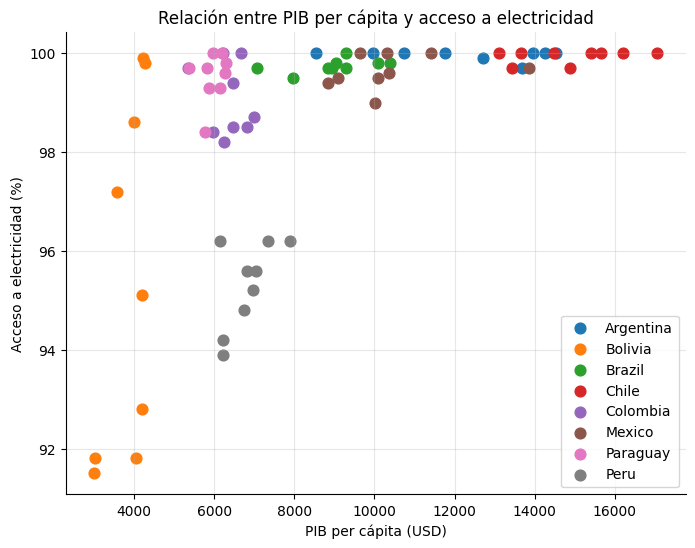

In [23]:
fig, ax = plt.subplots(figsize=(8,6))

for pais, grupo in df_combinado.groupby('pais_x'):
    ax.scatter(
        grupo['pib_pc_usd'],
        grupo['indicador2'],
        label=pais,
        s=60
    )

ax.set_xlabel('PIB per cápita (USD)')
ax.set_ylabel(nombre_indicador2)
ax.set_title('Relación entre PIB per cápita y acceso a electricidad')

ax.legend()
ax.grid(alpha=0.3)

plt.show()

# Task
Upload the current Colab notebook to the GitHub repository "https://github.com/jvargasa2/BigDataScraping".